In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import lfilter, remez
from scipy.constants import c
from scipy.constants import pi
from scipy import stats
from scipy import signal
from scipy import integrate
from scipy import interpolate
from astropy.io import ascii
import math as m

#### Spektar Sunca izvan atmosfere

In [2]:
### --- IMPORT extraterrestrial SUNSHINE 
exterre = ascii.read("Spctrm_0.dat")
wvlgth = exterre['Wvlgth']
exterre = exterre['Gueymard_2003']
exterre = exterre[:181]
wvlgth = wvlgth[:181]/10.0

#### Udarni presjek za apsorpciju na ozonu

In [3]:
### --- IMPORT UDARNOG PRESJEKA OZONA provided by SMARTS at 228 K 
###     (ne Gorshelev koji sam koristio na završnom)
abs_O3UV = ascii.read("Abs_O3UV.dat")
Wvl_full = abs_O3UV['Wvl_nm']
Wvl_nm = Wvl_full[:341]
cross_sec_full = abs_O3UV['Ref_228K']
cross_sec = cross_sec_full[:181]

#### Udarni presjek za apsorpciju na NO2

https://www.elsevier.es/en-revista-atmosfera-76-articulo-inference-surface-concentrations-nitrogen-dioxide-S0187623614711105

In [4]:
# NO2 absorption cross-section 
dataloc = 'No2_280h.dat'
# wl [nm], wn [cm-1], crossec [cm2/molec], crossecErr [cm2/molec]
dataNO2 = pd.read_csv(dataloc,delim_whitespace=True, skiprows=41,skipinitialspace=True, names = ["wl","wn","crossec","crossecErr"])
dataNO2[:2]

,wl,wn,crossec,crossecErr
0,800.00902,12499.859,1.203000e-21,4.331000e-23
1,799.99360,12500.100,1.266000e-21,4.558000e-23


In [5]:
# INTERPOLACIJA udarnih presjeka za NO2 za wvlgth array
# tablica je po padajućim valnim duljinama (počine na 800 nm i ide do 250nm),
# pa ju treba flip prije nego što se radi interpolacija 
crossNO2 = np.interp(wvlgth, np.flip(dataNO2.wl), np.flip(dataNO2.crossec), left=None, right=None, period=None)
len(crossNO2)

181

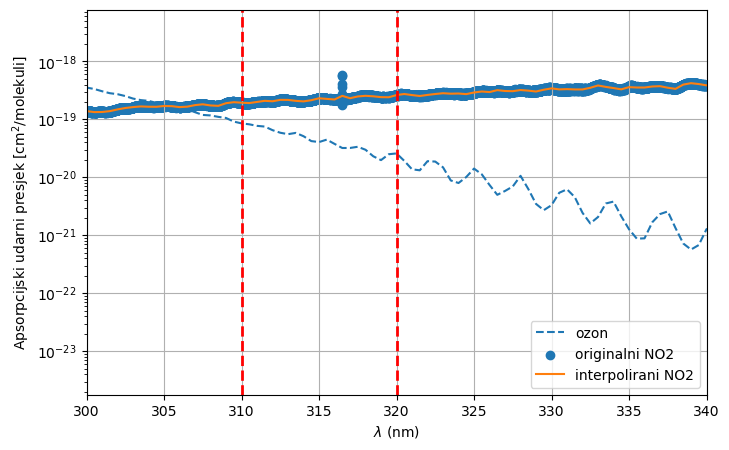

In [6]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(wvlgth , cross_sec, label='ozon',ls='--')
ax.scatter(dataNO2.wl , dataNO2.crossec, label='originalni NO2')
ax.plot(wvlgth , crossNO2, label='interpolirani NO2')
ax.set(xlim=(300,340))
ax.set(xlabel='$\lambda$ (nm)', ylabel='Apsorpcijski udarni presjek [cm$^2$/molekuli]')
ax.axvline(wvlgth[60], color='red', linestyle='--', lw=2)
ax.axvline(wvlgth[80], color='red', linestyle='--', lw=2)
ax.grid()
ax.set_yscale('log')
ax.legend(loc='best')
plt.show()
plt.close(fig)

### Relativna optička zračna masa

Vrlo je blizu 1/cos(zenith) ovisnosti, ali za svaki dio računa je malo različita.

Modeliranje je u obliku:
$$m_i = [\cos Z + a_{i1}Z^{a_{i2}}(a_{i3}-Z)^{a_{i4}}]^{-1}$$

$m_i$ stands for $m_R$ (Rayleigh), $m_a$ (aerosols), $m_o$ (ozone), $m_g$ (mixed gasses), $m_w$ (water vapor), $Z$ is the zenith angle and coefficients are given in the table 4.1. SMARTS paper
http://publications.energyresearch.ucf.edu/wp-content/uploads/2018/06/FSEC-PF-270-95.pdf

In [7]:
 # all SZA in degrees, relative optical air mass has no units
def air_mass_o(SZA): 
    a1_o = 2.6845e2        # air-mass ozone
    a2_o = 0.5
    a3_o = 115.420
    a4_o = -3.2922
    #air_mass_o = 
    return (np.cos(np.deg2rad(SZA)) + a1_o*SZA**a2_o * (a3_o-SZA)**a4_o)**-1

def air_mass_R(SZA): 
    a1_r = 4.5665e-1       # air-mass Rayleigh scattering
    a2_r = 0.07
    a3_r = 96.4836
    a4_r = -1.6970
    #air_mass_R = 
    return (np.cos(np.deg2rad(SZA)) + a1_r*SZA**a2_r * (a3_r-SZA)**a4_r)**-1

def air_mass_a(SZA): 
    a1_ae = 3.1141e-2      # air-mass aerosol scattering, also used for NO2
    a2_ae = 0.1
    a3_ae = 92.4710
    a4_ae = -1.3814
    #air_mass_ae = 
    return (np.cos(np.deg2rad(SZA)) + a1_ae*SZA**a2_ae * (a3_ae-SZA)**a4_ae)**-1


In [8]:
# These two values should be 38.136 and 16.601 at 90 degrees
# This is a sanity check from their paper
air_mass_R(90), air_mass_o(90)

(38.130427711637765, 16.601000790103477)

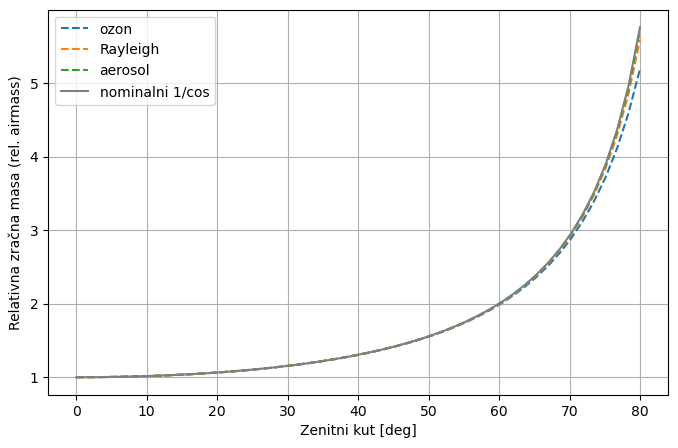

In [9]:
fig, ax = plt.subplots(figsize=(8,5))

zeniths = np.linspace(0,80,50) # iznad 80 ide do velikih vrijednosti
ax.plot(zeniths, air_mass_o(zeniths), label='ozon',ls='--')
ax.plot(zeniths, air_mass_R(zeniths), label='Rayleigh',ls='--')
ax.plot(zeniths, air_mass_a(zeniths), label='aerosol',ls='--')
ax.plot(zeniths, 1/np.cos(np.deg2rad(zeniths)), label='nominalni 1/cos',color='gray')
ax.set(xlabel='Zenitni kut [deg]', ylabel='Relativna zračna masa (rel. airmass)')

ax.grid()
ax.legend(loc='best')
plt.show()
plt.close(fig)

#### Provjera udarnih presjeka i apsorpcija sa slikom 4.2. u SMARTS paper

Na slici 4.2. u SMARTS paper su: 
$$m_o*u_o =[0.2, 0.5, 1.0, 2.5]$$
$$m_n*u_n =[10^{-3}, 5\cdot 10^{-3}, 0.01, 0.025]$$

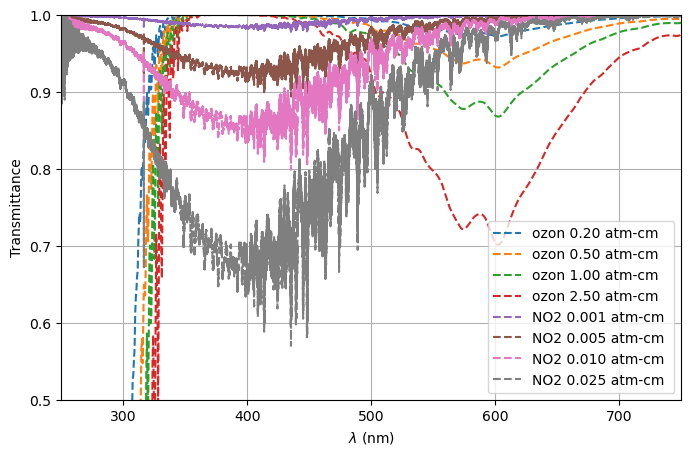

In [10]:
fig, ax = plt.subplots(figsize=(8,5))
sza=0
# drzim air mass na 1 (sza=0), a total pathlength u atm-cm kontroliram 
# pomoću du i ekvivalentom za NO2, duN
# U stvarnosti se neke od ovih vrijednosti atm-cm postižu samo za velike zenitne kuteve

#transmit_o3 = np.exp(-tau_o(wvlgth,du)*air_mass_o(sza))
#ax.plot(wvlgth , transmit_o3, label='ozon',ls='--')
for du in [200, 500, 1000, 2500]:
    transmit_o3 = np.exp(-2.687e16*cross_sec_full*du*air_mass_o(sza))
    label = "ozon %.2f atm-cm "%(du/1000)
    ax.plot(Wvl_full , transmit_o3, label=label,ls='--')

for duN in [1,5,10,25]:
    transmit_n = np.exp(-2.687e16*dataNO2.crossec*duN*air_mass_o(sza))
    label = "NO2 %.3f atm-cm "%(duN/1000)
    ax.plot(dataNO2.wl , transmit_n, label=label,ls='--')

ax.set(xlabel='$\lambda$ (nm)', ylabel='Transmittance')
ax.set(xlim=(250,750),ylim=(0.5,1))
ax.grid()
ax.legend(loc='best')
plt.show()
plt.close(fig)

Zoom na područje valnih duljina s kojima radimo:

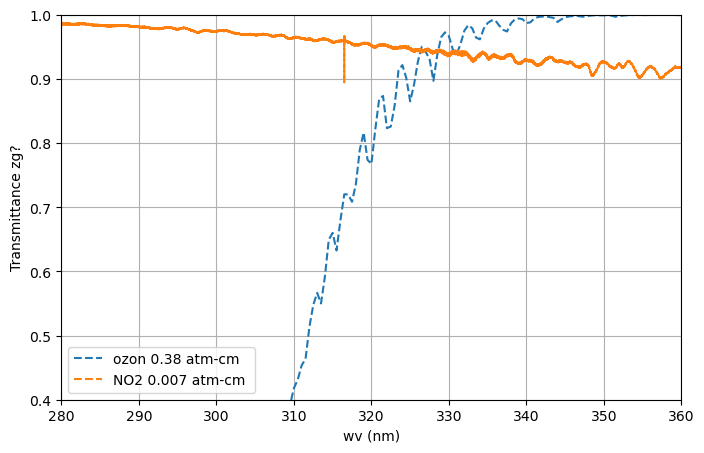

In [11]:
fig, ax = plt.subplots(figsize=(8,5))
sza =0
du = 380
transmit_o3 = np.exp(-2.687e16*cross_sec_full*du*air_mass_o(sza))
label = "ozon %.2f atm-cm "%(du/1000)
ax.plot(Wvl_full , transmit_o3, label=label,ls='--')

duN = 7 #3
transmit_n = np.exp(-2.687e16*dataNO2.crossec*duN*air_mass_o(sza))
label = "NO2 %.3f atm-cm "%(duN/1000)
ax.plot(dataNO2.wl , transmit_n, label=label,ls='--')
ax.set(xlabel='$x$',ylabel='$y$', title='')

ax.set(xlabel='wv (nm)', ylabel='Transmittance zg?')
ax.set(xlim=(280,360),ylim=(0.4,1))
ax.grid()
ax.legend(loc='best')
plt.show()
plt.close(fig)

## Ekstinkcije 
### Ozone apsorption

Bouger law: 
$$T_{o\lambda} = \exp (-m_o\tau_{o\lambda} )$$ where 
$$\tau_{0\lambda} = u_0 A_{0\lambda}$$
is the ozone optical thickness, $m_o$ its optical mass, $u_0$ its reduced path length in (atm-cm) and $A_{0\lambda}$ its spectral absorption coefficient.

Reference temperature is $T_{ro} = 228$ K.

### Rayleigh optical thickness

Rayleigh transmittance $T_{R\lambda}$ and optical thickness $\tau_{R\lambda}$:

$$T_{R\lambda} = \exp (-m_R\tau_{R\lambda} )= \exp [
-m_R P / (a_1 \lambda^4 + a_2 \lambda^2 + a_3  + a_4 \lambda^{-2})]$$

### Aerosols extinction

Aerosol transmittance is obtained from the optical thickness: 
$$T_{a\lambda} = \exp (-m_a\tau_{a\lambda} )$$ with 
$$\tau_{a\lambda} = \beta_i (\lambda/\lambda_1)^{-\alpha_i}$$

where $\lambda_1  = 1\,\mu$m,  $m_a$ is aerosol optical mass, $\alpha_i = \alpha_1$ for $\lambda < \lambda_0$, with $ \lambda_0=0.5\,\mu$m and $\beta_i = \beta_1 = 2^{\alpha_2-\alpha_1}\beta$ for $\lambda < \lambda_0$.

Reference temperature is $T_{ro} = 228$ K.




In [12]:
# P is the pressure coefficient P = p/p0, where p is the pressure at the site level 
# and p0 standard atm pressure, -- zašto je Kristian uzeo 820?
# 20.6. je cijeli dan tlak bio prilično stabilan, oko 1015, 25.6. na sljemenu slična vrijednost
psite = 1017
p0 = 1013.3
P = psite/p0        #ray = P*tau_R(wl)#P*exact_ray

#---------------- Apsorpcija na ozonu    
# 1 DU = 0.001 atm-cm, so 0.3 atm-cm = 300 DU.
def tau_o(wvlgth,DU):
    return 2.687e16*cross_sec*DU

# -------------- Rayleighovo raspršenje
def tau_R(wvlgth):
    a1 = 117.2594*1e-12  # 117   microm^(-4)        # SMARTS calculation
    a2 = -1.3215*1e-6    # -1.32 microm^(-2)
    a3 = 3.2073e-4       # 3.2073e-4
    a4 = -7.6842e-5*1e6  # -7.68 microm^(2)
    return 1/(a1*(wvlgth)**4 + a2*(wvlgth)**2 + a3 + a4*(wvlgth)**(-2)) #exact_ray =

# -------------- Raspršenje na aerosolima -- promijenjeno na urbani
def tau_a(wvlgth):  
    alfa1 = 0.822 # rural: 0.932
    alfa2 = 1.167 # rural: 1.441
    tau_a5 = 0.3442 # SMARTS2 value
    # nisam sigurna a ovo, dobije se 0.153 dolje: ang_beta = 0.0198
    ang_beta = tau_a5/(2**alfa2)  # prema ovome je 0.153
    #print(ang_beta)  
    beta1 = 2**(alfa2-alfa1)*ang_beta
    lam1 = 1000 #nm 
    return beta1*(wvlgth/lam1)**(-alfa1)
    # transmittance at 310-320 nm should be around 0.45   #aerosol =
    
#---------------- Apsorpcija na NO2 --ovdje se malo pogađalo, ali se dobije konzistentno
# u gradovima median 0.00166 atm-cm, raspon je 4.4e-5 do 0.013 atm-cm 
def tau_n(wvlgth,atmcmN):
    return 2.687e16*crossNO2*atmcmN*1000  

In [13]:
# angstrom model alpha = 1.3 -- does not apply to UV, but just to check
# ovo je isto jedan sanity check, ovaj je za aerosole
a_beta = 0.3442/(2**1.3)
a_beta
a_beta*(320/1000)**(-1.3), np.exp(-a_beta*(320/1000)**(-1.3)), tau_a(320)

(0.6148609330991631, 0.5407160857912254, 0.4967420524143203)

In [14]:
zgNO2duN = 5e15/2.687e16
zgNO2duN

0.18608113137327875

#### Spektralna osjetljivost fotodiode i propusnost filtera

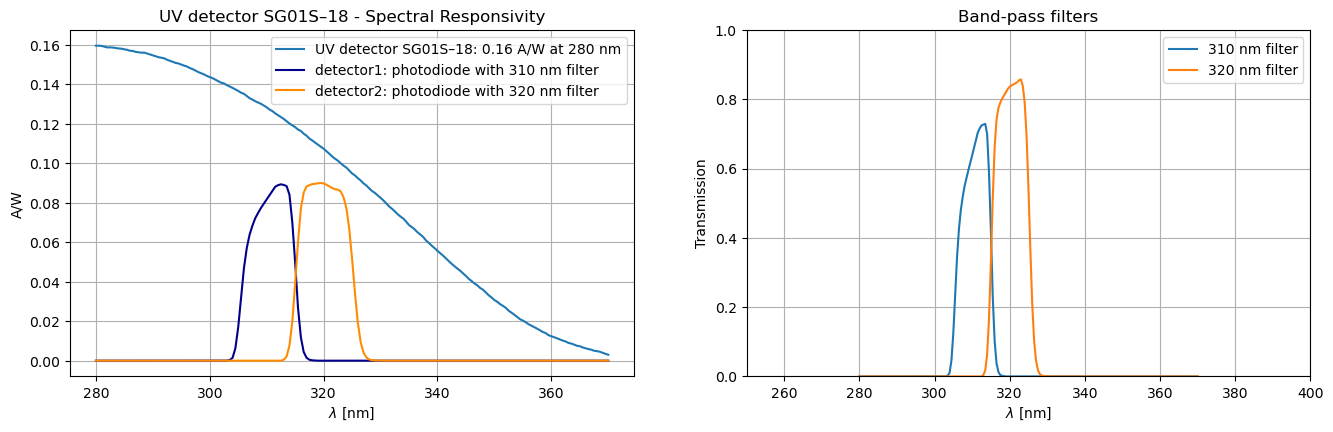

integral za detektor 1 = 0.770199577902841 [A/W]
integral za detektor 2 = 0.8944136474418795 [A/W]


In [15]:
### --- spektri propusnosti filtera i osjetljivosti detektora očitani u WebPlotDigitizer-u
S = 0.06e-6 # aktivna površina 0.06 mm^2

wv1, H1 = np.loadtxt('BP310.csv', delimiter=",", dtype = 'float', unpack=True)
wv2, H2 = np.loadtxt('BP320.csv', delimiter=",", dtype = 'float', unpack=True)
wvr, responsivity = np.loadtxt('responsivity.csv', delimiter=",", dtype = 'float', unpack=True)
R = responsivity * 0.160
wv = wvr # provjereno -- sve su valne duljine iste wv1, wv2, wvr

detector1 = R * H1    # sensor * 310nm filter
detector2 = R * H2    # sensor * 320nm filter

fig, ax = plt.subplots(1,2,figsize=(16,4.5))
ax[0].plot(wvlgth, R, label='UV detector SG01S–18: 0.16 A/W at 280 nm')
ax[0].plot(wvlgth, detector1, label='detector1: photodiode with 310 nm filter', color='darkblue')
ax[0].plot(wvlgth, detector2, label='detector2: photodiode with 320 nm filter', color='darkorange')
ax[0].set(xlabel='$\lambda$ [nm]', ylabel='A/W', title='UV detector SG01S–18 - Spectral Responsivity')
ax[0].grid()
ax[0].legend(loc='best')

ax[1].plot(wvlgth, H1, label='310 nm filter')
ax[1].plot(wvlgth, H2, label='320 nm filter')
ax[1].set(xlabel='$\lambda$ [nm]', ylabel='Transmission', title='Band-pass filters', xlim=(250,400), ylim=(0,1))
ax[1].grid()
ax[1].legend(loc='best')

plt.show()
plt.close(fig)

print("integral za detektor 1 =",integrate.simpson(detector1,x=wvlgth), "[A/W]")
print("integral za detektor 2 =",integrate.simpson(detector2,x=wvlgth),"[A/W]")

### Modeliranje prolaska zračenja kroz atmosferu

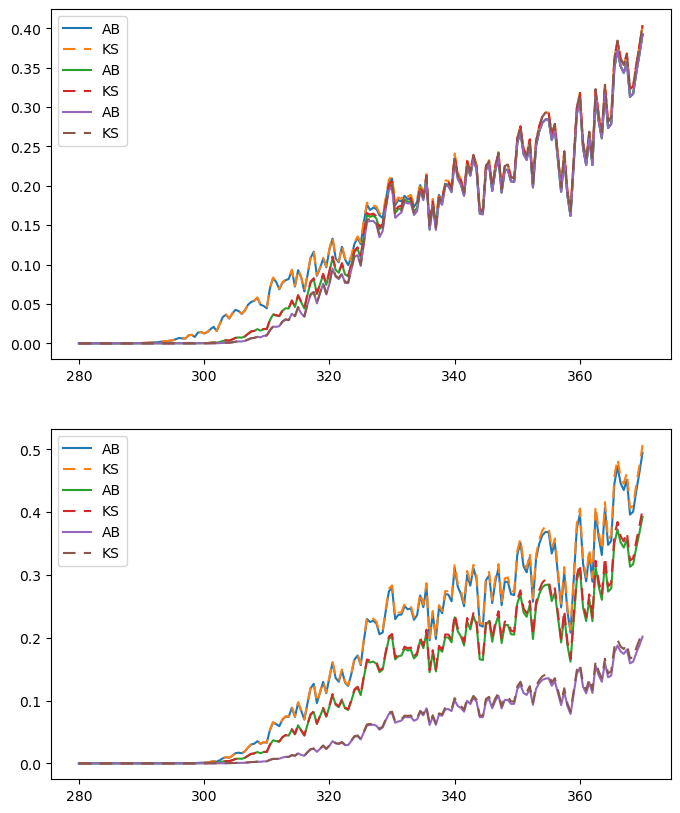

In [16]:
# Vraća zračenje Sunca nakon prolaska kroz atmosferu za zadani zenitni kut (stupnjevi)
# i stupac ozona u DU, može mu se zadati i stupac NO2 u atm-cm jedinicama, 
# pretpostavljena je niska vrijednost

def atmosphere(SZA, DU, atmcmN=0.00166):
    ## RELATIVNe OPTIČKe ZRAČNe MASe
    am_o = air_mass_o(SZA)
    am_R = air_mass_R(SZA)
    am_a = air_mass_a(SZA)
    
    #-------------- Rayleighovo raspršenje
    rayleigh = P*tau_R(wvlgth)*am_R          #P*exact_ray    
    #---------------- Apsorpcija na ozonu
    ozone = tau_o(wvlgth,DU)*am_o
    #-------------- Raspršenje na aerosolima
    aerosol = tau_a(wvlgth)*am_a          # beta*(wvlgth/lam1)**-alfa1
    # ------------- Apsorpcija na NO2, use aerosol airmass
    no2 = tau_n(wvlgth,atmcmN)*am_a
    
    #SURF_IRR = [x*np.exp(-y*am_o-z*am_R-k*am_a) for x,y,z,k in zip(exterre,ozone,ray,aerosol)]
    SURF_IRR = exterre*np.exp(-ozone-rayleigh-aerosol-no2) 
    return SURF_IRR

def atmosphere_KS(SZA, DU, atmcmN=0.00166):
    ps = 1017
    p0 = 1013.3
    ##------------- RELATIVNA OPTIČKA ZRAČNA MASA
    a1_o = 2.6845e2        # air-mass ozone
    a2_o = 0.5
    a3_o = 115.420
    a4_o = -3.2922
    air_mass_o = (np.cos(np.deg2rad(SZA)) + a1_o*SZA**a2_o * (a3_o-SZA)**a4_o)**-1
    a1_r = 4.5665e-1       # air-mass Rayleigh scattering
    a2_r = 0.07
    a3_r = 96.4836
    a4_r = -1.6970
    air_mass_R = (np.cos(np.deg2rad(SZA)) + a1_r*SZA**a2_r * (a3_r-SZA)**a4_r)**-1
    a1_ae = 3.1141e-2      # air-mass aerosol scattering
    a2_ae = 0.1
    a3_ae = 92.4710
    a4_ae = -1.3814
    air_mass_ae = (np.cos(np.deg2rad(SZA)) + a1_ae*SZA**a2_ae * (a3_ae-SZA)**a4_ae)**-1
    #-------------- Rayleighovo raspršenje
    aprox_ray = 1.787e10*wvlgth**-4.25*np.log(10)   # 1.787e10 x λ[nm]**-4.25                                               
                                                    # a simple approximation for the base 10
    a1 = 117.2594*1e-12   # SMARTS calculation
    a2 = -1.3215*1e-6
    a3 = 3.2073e-4
    a4 = -7.6842e-5*1e6
    exact_ray = (a1*(wvlgth)**4 + a2*(wvlgth)**2 + a3 + a4*(wvlgth)**-2)**-1
    ray = (ps/p0)*exact_ray
    #---------------- Apsorpcija na ozonu
    ozone = 2.687e16*cross_sec*DU
    #---------------- Apsorpcija na NO2
    NO2 = 2.687e16*crossNO2*atmcmN*1000
    #-------------- Raspršenje na aerosolima
    alfa1 = 0.827
    alfa2 = 1.171
    tau_a5 = 0.3442 # SMARTS2 value
    # nisam sigurna a ovo, dobije se 0.153 dolje: ang_beta = 0.0198
    ang_beta = tau_a5/(2**alfa2)  # prema ovome je 0.153
    #print(ang_beta)  
    beta1 = 2**(alfa2-alfa1)*ang_beta
    lam1 = 1000 #nm
    aerosol = beta1*(wvlgth/lam1)**-alfa1
    
    SURF_IRR = [x*np.exp(-y*air_mass_o-z*air_mass_R-k*air_mass_ae) for x,y,z,k in zip(exterre,ozone,ray,aerosol)]
    return SURF_IRR

fig, ax = plt.subplots(2,1,figsize=(8,10))
for du in [100,400,600]:
    irr_AB = atmosphere(40, du, atmcmN=0.00166)
    irr_KS = atmosphere_KS(40, du, atmcmN=0.00166)
    ax[0].plot(wvlgth, irr_AB, label='AB')
    ax[0].plot(wvlgth, irr_KS, dashes=[6,4], label='KS')
    ax[0].legend(loc='best')
    
for z in [20,40,60]:
    irr_AB = atmosphere(z, 400, atmcmN=0.00166)
    irr_KS = atmosphere_KS(z,400, atmcmN=0.00166)
    ax[1].plot(wvlgth, irr_AB, label='AB')
    ax[1].plot(wvlgth, irr_KS, dashes=[6,4], label='KS')
    ax[1].legend(loc='best')

plt.show()
plt.close(fig)

In [17]:
# Ovo su snage, bez da je uzeta u obzir aktivna površina, cilj je samo dobiti omjer
def detector310_power(SZA, DU,atmcmN=0.00166 ):
    return integrate.simpson(detector1*atmosphere(SZA, DU,atmcmN),x=wvlgth)
def detector320_power(SZA, DU,atmcmN=0.00166):
    return integrate.simpson(detector2*atmosphere(SZA, DU,atmcmN),x=wvlgth)
def ratio_310_over_320(SZA, DU,atmcmN=0.00166):
    return detector310_power(SZA, DU,atmcmN)*1.04/detector320_power(SZA, DU,atmcmN)
# VAŽNO: omjer je promijenjen tako da za slučaj jednakih snaga na detektorima NE daje 1, već 1.06
# jer je tako mjereno za difuzno zračenje BEZ FILTERA - detektori ne daju isti napon pri istom osvjetljenju

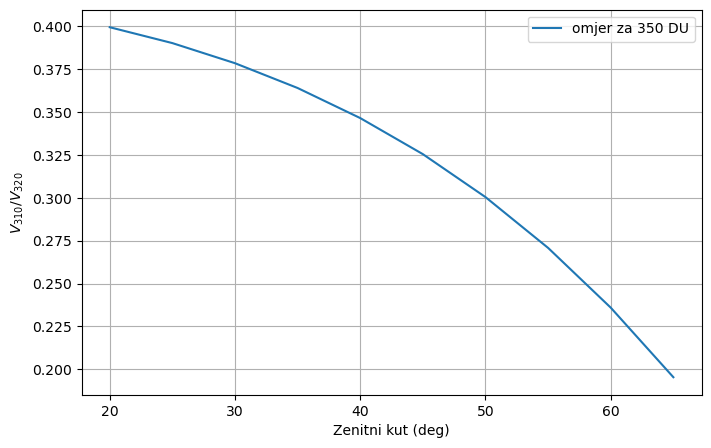

In [18]:
# Ovisnost omjera napona o zenitnom kutu
fig, ax = plt.subplots(figsize=(8,5))

zeniths = np.linspace(20,65,10)
du = 350
ys = np.array([ratio_310_over_320(sza, du, 0.0166) for sza in zeniths])  
ax.plot(zeniths, ys, label='omjer za 350 DU')
ax.set(xlabel='Zenitni kut (deg)', ylabel='$V_{310}/V_{320}$')
ax.grid()
ax.legend(loc='best')
plt.show()
plt.close(fig)

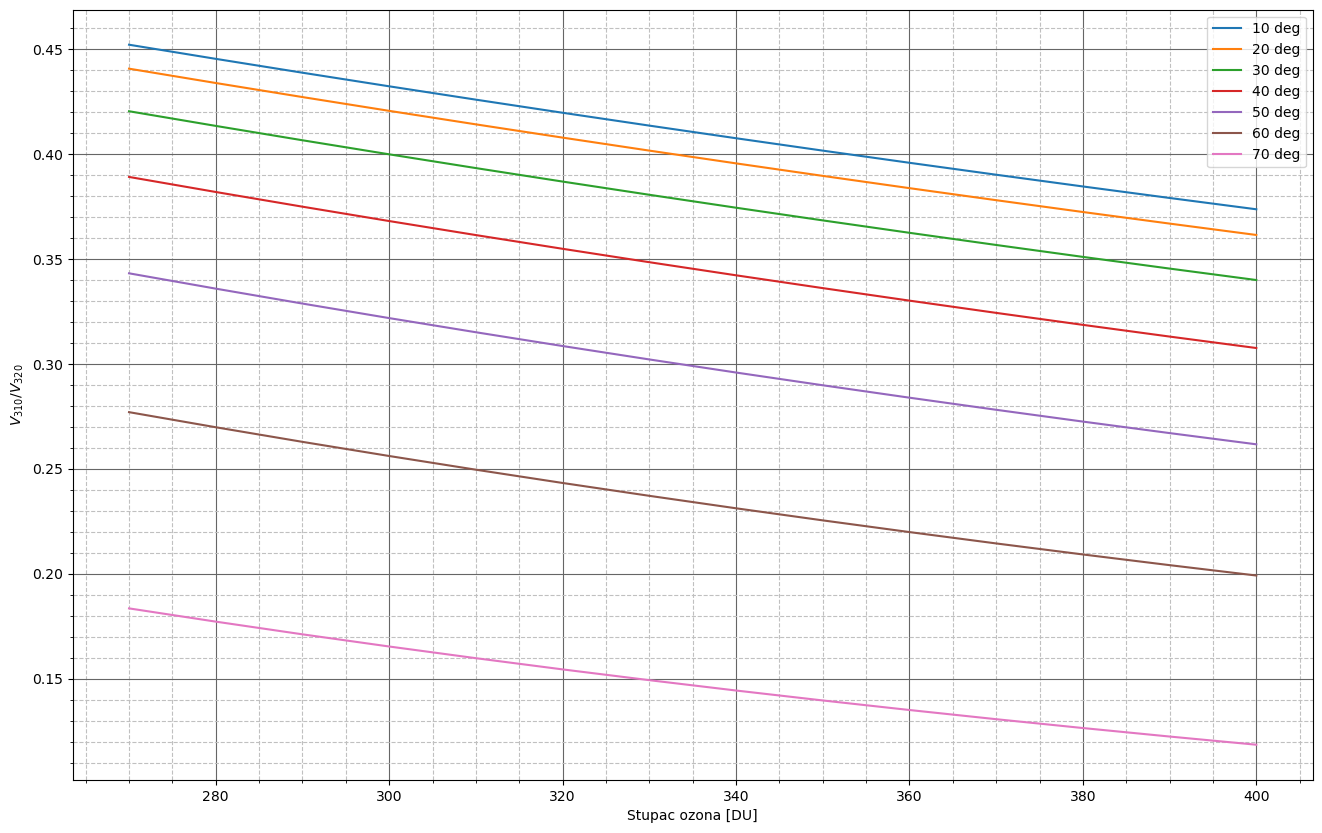

In [19]:
fig, ax = plt.subplots(figsize=(16,10))

dus = np.linspace(270,400,14)
for sza in np.linspace(10,70,7):
    myratio = np.array([ratio_310_over_320(sza,dob) for dob in dus])
    ax.plot(dus,myratio,linestyle='-', label="{} deg".format(int(sza))) #color=plt.gca().lines[-1].get_color()
ax.set(xlabel='Stupac ozona [DU]', ylabel='$V_{310}/V_{320}$')
ax.grid( which='major', color='#666666', linestyle='-')
ax.grid(which='minor', color='silver', linestyle='--')
ax.minorticks_on()
ax.legend(loc='best')

plt.show()
plt.close(fig)

Kako izgleda tipična situacija za zenitni kut 35 stupnjeva i raspon stupaca ozona

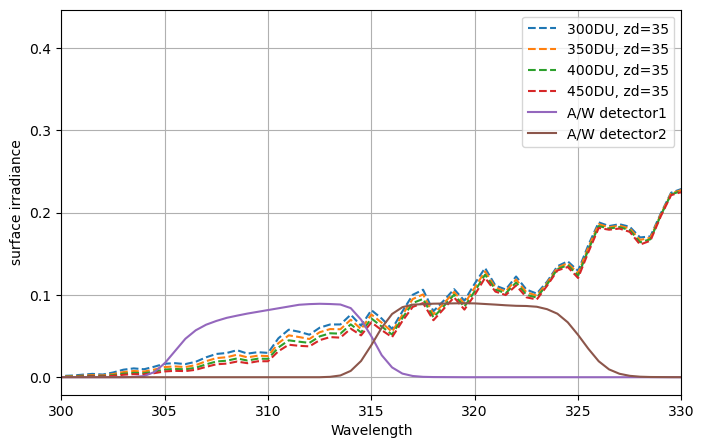

In [20]:
fig, ax = plt.subplots(figsize=(8,5))

zeniths = np.linspace(0,80,50)
for du in [300,350,400,450]:
    for sza in [35]: #[25,35,45,55]:
        ax.plot(wvlgth, atmosphere(sza,du), label=str(du)+'DU, zd='+str(sza),ls='--')
ax.plot(wvlgth, detector1, label='A/W detector1')
ax.plot(wvlgth, detector2, label='A/W detector2')

ax.set(xlabel='Wavelength', ylabel='surface irradiance')
ax.set(xlim=(300,330))
ax.grid()
ax.legend(loc='best')
plt.show()
plt.close(fig)

### Položaj Sunca

In [21]:
from astropy.coordinates import get_sun, AltAz, EarthLocation
import astropy.coordinates as coord
from astropy.time import Time
import astropy.units as u
import time

# lokacija FERa  45.80151599828732, 15.971002581428651
loc = coord.EarthLocation(lon=15.971002581428651 * u.deg, lat=45.80151599828732 * u.deg)
geo = loc.geodetic

In [23]:
# Array za više sati -- u odnosu na UTC podne
deltat = np.linspace(-3, 7, 21)*u.hour
times = Time('2013-6-22 12:00:00', scale='utc') + deltat
#sun = coord.get_sun(times)
#for t in times:
    
altaz1 =coord.AltAz(location=loc, obstime=times)
altitudes = get_sun(times).transform_to(altaz1).alt
azimuths = get_sun(times).transform_to(altaz1).az
zeniths = 90-altitudes.degree

times, zeniths

TypeError: concatenate() got an unexpected keyword argument 'dtype'

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(deltat, zeniths, label='xx')
ax.set(xlabel='Vrijeme od UTC podneva', ylabel='Zenitni kut (deg)')
ax.grid()
#ax.legend(loc='best')
plt.show()
plt.close(fig)

In [ ]:
fig, ax = plt.subplots(figsize=(12,5))

ys1 = np.array([ratio_310_over_320(zd,310) for zd in zeniths])
ys2 = np.array([ratio_310_over_320(zd,350) for zd in zeniths])
ys3 = np.array([ratio_310_over_320(zd,390) for zd in zeniths])
ax.plot(deltat, ys1, label='za 310 DU')
ax.plot(deltat, ys2, label='za 350 DU')
ax.plot(deltat, ys3, label='za 390 DU')
ax.set(xlabel='Vrijeme od UTC podneva', ylabel='$V_{310}/V_{320}$')
ax.grid( which='major', color='#666666', linestyle='-')
ax.grid(which='minor', color='silver', linestyle='--')
ax.minorticks_on()
ax.legend(loc='best')
plt.show()
plt.close(fig)

Primjer za jedno zadano vrijeme ili trenutno vrijeme

In [ ]:
utc_time = Time.now() # UTC time
#utc_time = Time('2023-06-25 13:29:00',scale='utc') # zadano vrijeme
local_clock = utc_time + 2*u.hour
sun = coord.get_sun(utc_time)
print(sun)
print("Location:", loc)
print("Time/date: ", local_clock, "(local) or ", utc_time, "(UTC)" )
print("--------DEGREES--------")
sun = coord.get_sun(utc_time)
altaz = coord.AltAz(location=loc, obstime=utc_time)
current_altitude = get_sun(utc_time).transform_to(altaz).alt
current_azimuth = get_sun(utc_time).transform_to(altaz).az
geo = loc.geodetic
print("Time:        ", utc_time)
print("Loc. lat.:   ", geo.lat)
print("Loc. lon.:   ", geo.lon)
print("Sun alt.:   ", current_altitude.degree)
print("Sun zd.:   ", 90-current_altitude.degree)
print("Sun az.:    ", current_azimuth.degree)
print("---------------------------------------------------")

In [ ]:

ratio_310_over_320(90-66.54,453,0.00166),ratio_310_over_320(90-66.54,455,0.00166)

In [ ]:
deltat = np.linspace(0, 75/60., 21)*u.hour
times = Time('2013-6-30 12:27:45', scale='utc') + deltat
altaz1 =coord.AltAz(location=loc, obstime=times)
altitudes = get_sun(times).transform_to(altaz1).alt
azimuths = get_sun(times).transform_to(altaz1).az
zeniths = 90-altitudes.degree
times, zeniths

i, meanV1, meanV2, meanRatio, stdV1, stdV2, stdRatio, el = np.loadtxt('../Photodiode current3/ozone_3006_1.csv', delimiter=",", dtype = 'float’, unpack=True,skiprows=5)
fig, ax = plt.subplots(1,1,figsize=(7,4))
ax.plot(i/60, meanRatio, linestyle='-')
ax.errorbar(i/60, meanRatio, stdRatio, color='blue',ls='None',marker='o',markersize=5.,alpha=0.1)
ys1 = np.array([ratio_310_over_320(zd,410) for zd in zeniths])
ys2 = np.array([ratio_310_over_320(zd,420) for zd in zeniths])
ys3 = np.array([ratio_310_over_320(zd,430) for zd in zeniths])
ax.plot(deltat*60, ys1, label='410 DU', color='black',linestyle=':')
ax.plot(deltat*60, ys2, label='420 DU', color='black',linestyle='-')
ax.plot(deltat*60, ys3, label='430 DU', color='black',linestyle='--')
ax.set(ylim=(0.25,0.37))
ax.set(xlabel='Vrijeme od 14:27 (u min.)', ylabel='Omjer napona (310/320)',title='Mjerenja 30. 6. 2023.')
ax.legend(loc='best')
ax.grid()
plt.show()
plt.close(fig)

### Probna mjerenja sa zamjenama filtera

In [ ]:
## MJERENJE 20.6.2023. između 11:45h i 12.18h sa zamjenama filtera (SZA=[24,25,26,27])
## vXY : X = pojačalo, Y = stupanj
# i1 = v1_1/1e7*1e9,     i2 = v2_1/1e7*1e9

darkV_p1_st1 = 0.1  # mV
darkV_p2_st1 = 0.13 # mV
darkV_p1_st2 = 0.0024 # V
darkV_p2_st2 = 0.0068 # V

v_p1_st1_310 = np.array([9.44,10,   10.54,9.75])  #,9.38])  # mV
v_p1_st1_320 = np.array([33,  33.36,33.32,30.54])  # mV
v_p2_st1_310 = np.array([9.45,9.31,9.26,8.78])      # mV
v_p2_st1_320 = np.array([30.2,30.71,31.2,29.16]) #,28.5]) # mV


v_p1_st2_310 = np.array([0.85,0.88,0.941,0.866])#,0.848]) # V
v_p2_st2_310 = np.array([0.42,0.414,0.411,0.401]) # V
v_p1_st2_320 = np.array([2.958,2.98,2.96,2.866]) # V
v_p2_st2_320 = np.array([1.375,1.376,1.388,1.334]) #,1.29]) # V

#print("Odnosi napona na prvom stupnju 310/320 :\n{}{}".format(v11_310/v21_320,v21_310/v11_320))

mjerenja1=np.array([1,2,3,4,5])
mjerenja2=np.array([1,2,3,4])

fig, ax = plt.subplots(1,3,figsize=(16,5))

ax[0].plot(mjerenja2, v_p1_st1_310-darkV_p1_st1, linestyle='-', marker='o', label='kanal 1, 310')
ax[0].plot(mjerenja2, v_p2_st1_310-darkV_p2_st1, linestyle='-', color='blue', marker='o', label='kanal 2, 310')
ax[0].plot(mjerenja2, v_p1_st1_320-darkV_p1_st1, linestyle='-', marker='o', label='kanal 1, 320')
ax[0].plot(mjerenja2, v_p2_st1_320-darkV_p2_st1, linestyle='-', color='orange', marker='o', label='kanal 2, 320')
ax[0].set(xlabel='', ylabel='Napon [mV]')
ax[0].grid()
ax[0].legend(loc='best')

ax[1].plot(mjerenja2, (v_p1_st1_310-darkV_p1_st1)/(v_p1_st1_320-darkV_p1_st1), linestyle='-', marker='o', label='omjer kanala 1')
ax[1].plot(mjerenja2, (v_p2_st1_310-darkV_p2_st1)/(v_p2_st1_320-darkV_p2_st1), linestyle='-', marker='o', label='omjer kanala 2')
ax[1].legend(loc='best')
ax[1].grid()

ax[2].plot(mjerenja2, (v_p1_st1_310-darkV_p1_st1)/(v_p2_st1_310-darkV_p2_st1), linestyle='-', marker='o', label='k1/k2 s 310')
ax[2].plot(mjerenja2, (v_p1_st1_320-darkV_p1_st1)/(v_p2_st1_320-darkV_p2_st1), linestyle='-', marker='o', label='k1/k2 s 320')
ax[2].legend(loc='best')
ax[2].grid()

plt.show()
plt.close(fig)

In [ ]:
pojacanje1 = v_p1_st2_310 /v_p1_st1_310*1000
pojacanje1, np.mean(pojacanje1), np.std(pojacanje1)

In [ ]:
pojacanje2 = v_p2_st2_310/v_p2_st1_310*1000
pojacanje2, np.mean(pojacanje2), np.std(pojacanje2)

In [ ]:
pojacanje1[:4]/pojacanje2, np.mean(pojacanje1[:4]/pojacanje2)

In [ ]:
svi_omjeri_p1_over_p2 = np.array( [(v_p1_st1_310-darkV_p1_st1)/(v_p2_st1_310-darkV_p2_st1), (v_p1_st1_320-darkV_p1_st1)/(v_p2_st1_320-darkV_p2_st1)]).ravel()
np.mean(svi_omjeri_p1_over_p2), np.std(svi_omjeri_p1_over_p2), svi_omjeri_p1_over_p2

### Mjerenja tijekom  više sati, bez usmjeravanja

In [ ]:
with open('mjerenja20230622.csv') as f:
    lines = f.readlines()
zeniths = []
tmpratios = []
tmp310 = []; tmp320 = []
ratios = []
ratioErr = []
V310 = []; V320 = []
for lin in lines:  
    if lin.find("El")>0: 
        tmp = lin.split("El:")
        zeniths.append(90-float(tmp[-1]))
        if (len(tmpratios)>0): 
            ratios.append(np.mean(np.array(tmpratios)))
            ratioErr.append(np.std(np.array(tmpratios)))
        if (len(tmp310)>0): 
            V310.append(np.mean(np.array(tmp310)))
        if (len(tmp320)>0): 
            V320.append(np.mean(np.array(tmp320)))
        tmpratios = []
        tmp310 = []; tmp320 = []
    if lin.find("at")>0: # Ratio
        tmp = lin.split(":")
        #print(tmp[-1])
        tmpratios.append(float(tmp[-1]))
    if lin.find("310 :")>0: # Ratio
        tmp = lin.split(":")
        #print(tmp[-1])
        tmp310.append(float(tmp[-1]))
    if lin.find("320 :")>0: # Ratio
        tmp = lin.split(":")
        #print(tmp[-1])
        tmp320.append(float(tmp[-1]))
np.array(zeniths)[:-1], np.array(ratios),np.array(ratioErr),np.array(V310),np.array(V320)


In [ ]:
fig, ax = plt.subplots(figsize=(15,5))
#ax.plot(zeniths[:-1], np.array(V310), color='blue', marker='o')
ax.plot(np.arange(len(V310)), np.array(V310),  marker='o')
ax.plot(np.arange(len(V310)), np.array(V320)*2,marker='o')

#ax.plot(1/np.cos(np.deg2rad(zeniths[:-1])), np.log(np.array(V310)), color='blue', marker='o')

ax.set(xlabel='timeslices', ylabel='Voltage 310')
plt.show()
plt.close(fig)

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(np.arange(len(V310)), np.array(ratios), marker='o')
ax.plot(np.arange(len(V310)), np.array(V310)/1.02/np.array(V320)/2, marker='o')

ax.set(xlabel='timeslices', ylabel='ratios')
plt.show()
plt.close(fig)

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(zeniths[:800], np.array(V310)[:800], color='blue', marker='o')
#ax.plot(np.arange(len(V310))[:800], np.array(V310)[:800], color='blue', marker='o')

#ax.plot(1/np.cos(np.deg2rad(zeniths[:-1])), np.log(np.array(V310)), color='blue', marker='o')

ax.set(xlabel='Zenith angle', ylabel='Voltage 310')
plt.show()
plt.close(fig)

In [ ]:
fig, ax = plt.subplots(figsize=(16,10))

ax.errorbar(zeniths[:800], np.array(ratios)[:800], np.array(ratioErr)[:800], linestyle='-', marker='o',alpha = 0.5 )
ax.plot(zeniths[:800], np.array(ratios)[:800], color='blue', marker='o')
ax.set(xlabel='Zenith angle', ylabel='Voltage ratio')

plt.show()
plt.close(fig)

## Ne koristi se

In [ ]:
DU =[250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360,380,400]

In [ ]:
### --- KOLIKA STRUJA JE NA IZLAZU DETEKTORA
# I = S * integrate.simps(IRR_DU_W[i] * detector1,dx=0.5) * 1e9
###   KOLIKO OSVJETLJENJE [uW/cm^2] UPADA NA DETEKTOR
#W = integrate.simps(IRR_DU_W[i]*1e6*1e-4 * H1,dx=0.5)    # uW / cm^2
###   KOLIKA SNAGA SVJETLA [uW] UPADA NA DETEKTOR
#     W = S * integrate.simps(IRR_DU_W[i]*1e9 * H1,dx=0.5)    # nW

In [ ]:
### --- IMPORT tediously SIMULATED SUNSHINE with SMARTS

### --- WINTER : 'MLW', Z = 70
DU300W = ascii.read("winter_300.txt")['Direct_normal_irradiance'][:181]
### --- SUMMER : 'MLS', Z = 25
DU300S = ascii.read("summer300.txt")['Direct_normal_irradiance'][:181]
### --- SUMMER : 'MLS', Z = 70
DU300 = ascii.read("ljeto300.txt")['Direct_normal_irradiance'][:181]
fig, ax = plt.subplots(figsize=(16,9))
ax.plot(wvlgth, exterre, label='Spctrm_0 : Gueymard_2003 Extraterrestrial Spectrum')
ax.plot(wvlgth, DU300W, label='Spctrm_300DUW, z=70 : Direct Normal Irradiance Spectrum')
ax.plot(wvlgth, DU300S, label='Spctrm_300DUS, z=25 : Direct Normal Irradiance Spectrum')
ax.plot(wvlgth, DU300, label='Spctrm_300DU,z=70 : Direct Normal Irradiance Spectrum')
ax.set(xlabel='$\lambda$ [nm]', ylabel='$I_\lambda$ [W m$^{-2}$ nm$^{-1}$]',title='Beam normal irradiance for 250, 300 and 350 DU ozone')
#      xlim=(295,330), ylim=(0,0.2))
ax.legend(loc='best')
plt.show()
plt.close(fig)

In [ ]:
### --- RAZLIKA IZMEĐU LJETNE I ZIMSKE ATMOSFERE ZA ISTI ZENITNI KUT

print("Relative difference at 310 nm : {}".format((DU300W[60]-DU300[60])/DU300[60]))
print("Relative difference at 320 nm : {}".format((DU300W[80]-DU300[80])/DU300[80]))

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(16,4.5))

ax[0].plot(wvlgth, DU300S * detector1, label='Irr(300 DU) * detector1')
ax[0].plot(wvlgth, DU300S * detector2, label='Irr(300 DU) * detector2')
ax[0].plot(wvlgth, DU350S * detector1, label='Irr(350 DU) * detector1')
ax[0].plot(wvlgth, DU350S * detector2, label='Irr(350 DU) * detector2')

ax[0].set(xlabel='$\lambda$ [nm]', ylabel='Irr',)
ax[0].grid()
ax[0].legend(loc='best')

ax[1].plot(wvlgth, DU350S * detector1, label='Irr(350 DU) * detector1')
ax[1].plot(wvlgth, DU350S * detector2, label='Irr(350 DU) * detector2')
ax[1].set(xlabel='$\lambda$ [nm]', ylabel='Irr')
ax[1].grid()
ax[1].legend(loc='best')

plt.show()
plt.close(fig)